In [3]:
import numpy as np
import matplotlib.pyplot as plt

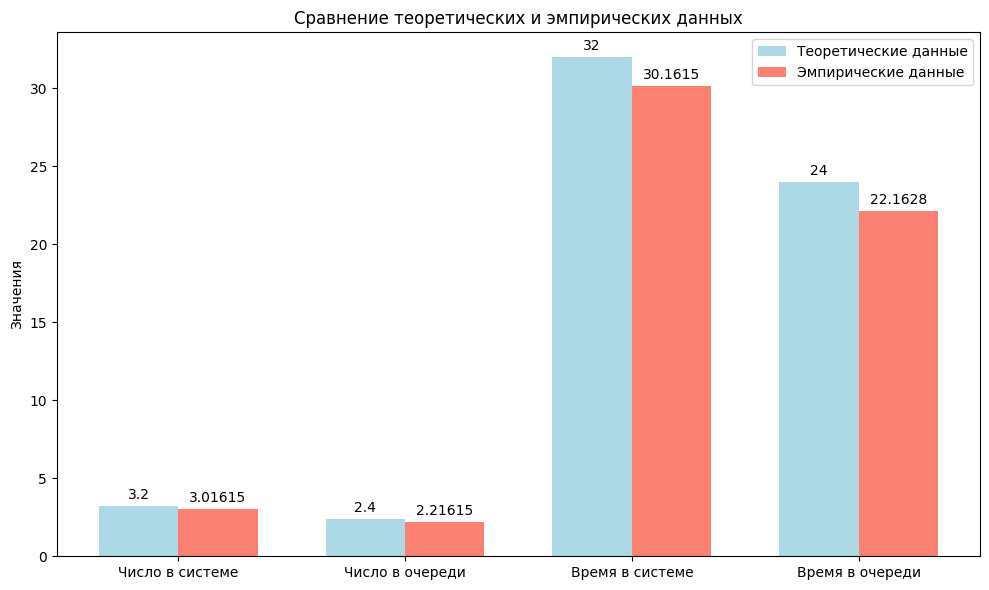

In [6]:

t_interarrival = 10   

t_service_mean = 8  

num_requests = 10000   

interarrival_times = np.random.exponential(scale=t_interarrival, size=num_requests)
service_times = np.random.gamma(shape=3, scale=t_service_mean/3, size=num_requests)  

arrival_times = np.cumsum(interarrival_times)

completion_times = np.zeros(num_requests)
waiting_times = np.zeros(num_requests)

for i in range(num_requests):
    if i == 0:
        completion_times[i] = arrival_times[i] + service_times[i]
    else:
        start_service_time = max(arrival_times[i], completion_times[i-1])
        waiting_times[i] = start_service_time - arrival_times[i]
        completion_times[i] = start_service_time + service_times[i]

average_in_system = np.mean(completion_times - arrival_times)
average_in_queue = np.mean(waiting_times)
average_requests_in_system = np.mean(completion_times - arrival_times) / t_interarrival
average_requests_in_queue = average_requests_in_system - (0.1 / 0.125)  

lambda_rate = 1 / t_interarrival
mu = 1 / t_service_mean
rho = lambda_rate / mu

theoretical_requests_in_system = rho**2 / (1 - rho)
theoretical_requests_in_queue = theoretical_requests_in_system - rho
theoretical_time_in_system = theoretical_requests_in_system / lambda_rate
theoretical_time_in_queue = theoretical_requests_in_queue / lambda_rate

labels = [
    'Число в системе',
    'Число в очереди',
    'Время в системе',
    'Время в очереди'
]

theoretical_data = [
    theoretical_requests_in_system,
    theoretical_requests_in_queue,
    theoretical_time_in_system,
    theoretical_time_in_queue
]

simulated_data = [
    average_requests_in_system,
    average_requests_in_queue,
    average_in_system,
    average_in_queue
]

x = np.arange(len(labels))  
width = 0.35  

fig, ax = plt.subplots(figsize=(10, 6)) 
bars1 = ax.bar(x - width/2, theoretical_data, width, label='Теоретические данные', color='lightblue')
bars2 = ax.bar(x + width/2, simulated_data, width, label='Эмпирические данные', color='salmon')

ax.bar_label(bars1, padding=3, fontsize=10)
ax.bar_label(bars2, padding=3, fontsize=10)

ax.set_ylabel('Значения')
ax.set_title('Сравнение теоретических и эмпирических данных')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()
